In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load forecast results for all models
models = ['lstm', 'transformer', 'transformer_d']
results = {}

for model in models:
    csv_path = f'../models_and_metrics/{model}_28day_forecast.csv'
    if os.path.exists(csv_path):
        results[model] = pd.read_csv(csv_path)
        print(f"Loaded {model}: {len(results[model])} predictions")
    else:
        print(f"{csv_path} not found")

print(f"\nTotal unique items: {results['lstm']['item_id'].nunique()}")


Loaded lstm: 40236 predictions
Loaded transformer: 40236 predictions
Loaded transformer_d: 40236 predictions

Total unique items: 1437


In [13]:
# Strategy for selecting representative items:
# 1. Medium sales volume (median) - typical case
# 2. High sales volume (75th percentile) - high-demand item
# 3. Low but non-zero sales - sparse data challenge
# 4. High variance - challenging forecasting case

def find_representative_items(df):
    """Find representative items based on different criteria."""
    item_stats = df.groupby('item_id').agg({
        'true_real': ['mean', 'std', 'max', lambda x: (x > 0).sum()],
    }).round(2)
    item_stats.columns = ['true_mean', 'true_std', 'true_max', 'non_zero_days']
    
    # Calculate MAE per item
    item_mae = df.groupby('item_id').apply(
        lambda g: np.mean(np.abs(g['true_real'] - g['pred_real'])),
        include_groups=False
    )
    item_stats['mae'] = item_mae
    
    candidates = {}
    
    # 1. Medium sales (around median)
    median_val = item_stats['true_mean'].median()
    med_items = item_stats[abs(item_stats['true_mean'] - median_val) < 1.0]
    if len(med_items) > 0:
        candidates['medium'] = med_items.nsmallest(1, 'mae').index[0]
    
    # 2. High sales (75th percentile)
    high_threshold = item_stats['true_mean'].quantile(0.75)
    high_items = item_stats[item_stats['true_mean'] >= high_threshold]
    if len(high_items) > 0:
        candidates['high'] = high_items.nsmallest(1, 'mae').index[0]
    
    # 3. Low but non-zero
    low_items = item_stats[(item_stats['true_mean'] > 0) & 
                           (item_stats['true_mean'] <= item_stats['true_mean'].quantile(0.25))]
    if len(low_items) > 0:
        candidates['low'] = low_items.nsmallest(1, 'mae').index[0]
    
    # 4. High variance (challenging)
    high_var_items = item_stats.nlargest(5, 'true_std')
    if len(high_var_items) > 0:
        candidates['high_variance'] = high_var_items.index[0]
    
    return candidates, item_stats

candidates, item_stats = find_representative_items(results['lstm'])

print("=== Representative Items ===")
for category, item_id in candidates.items():
    stats = item_stats.loc[item_id]
    print(f"{category:15s}: {item_id:20s} | Mean: {stats['true_mean']:6.2f} | Std: {stats['true_std']:6.2f} | MAE: {stats['mae']:6.2f}")

# Default selection: medium sales volume
selected_item = candidates.get('high_variance', list(candidates.values())[0] if candidates else 'FOODS_1_001')
print(f"\n Selected item for analysis: {selected_item}")


=== Representative Items ===
medium         : FOODS_3_745          | Mean:   0.14 | Std:   0.45 | MAE:   0.14
high           : FOODS_2_201          | Mean:   2.82 | Std:   1.39 | MAE:   0.79
low            : FOODS_2_292          | Mean:   0.07 | Std:   0.26 | MAE:   0.07
high_variance  : FOODS_3_120          | Mean:  43.14 | Std:  21.08 | MAE:  11.09

 Selected item for analysis: FOODS_3_120


Saved figure to ../images/true_vs_pred_FOODS_3_120.png


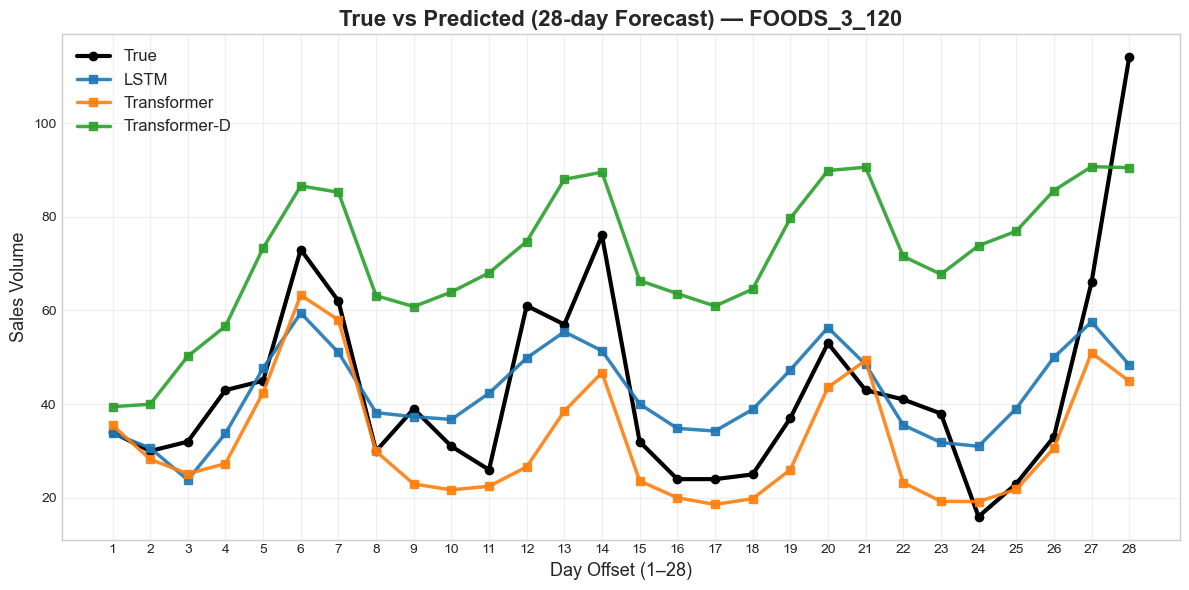

In [14]:
import matplotlib.pyplot as plt

def plot_all_models_one_figure(results_dict, item_id, save_path=None):
    """
    Plot True vs Predictions for all models in one figure.
    
    results_dict example:
    {
        "lstm": df_lstm,
        "transformer": df_trans,
        "transformer_d": df_trans_d
    }
    """
    
    # --- Prepare figure ---
    plt.figure(figsize=(12, 6))
    
    # --- Colors for models ---
    COLORS = {
        "True": "black",
        "LSTM": "#1f77b4",          # blue
        "Transformer": "#ff7f0e",   # orange
        "Transformer-D": "#2ca02c"  # green
    }
    
    # --- 1. Plot TRUE ---
    # All model CSVs share the same "true_real", so take from the first entry
    first_df = list(results_dict.values())[0]
    true_data = first_df[first_df["item_id"] == item_id].sort_values("day_offset")
    
    plt.plot(
        true_data["day_offset"], true_data["true_real"],
        label="True",
        color=COLORS["True"],
        linewidth=3,
        marker="o"
    )
    
    # --- 2. Plot predictions from each model ---
    for model_name, df in results_dict.items():
        item_df = df[df["item_id"] == item_id].sort_values("day_offset")
        
        pretty_name = model_name.replace("_", " ").title()  # lstm → Lstm (we will manually adjust below)
        if pretty_name == "Lstm": pretty_name = "LSTM"
        if pretty_name == "Transformer D": pretty_name = "Transformer-D"
        
        plt.plot(
            item_df["day_offset"],
            item_df["pred_real"],
            label=pretty_name,
            linewidth=2.5,
            marker="s",
            alpha=0.9,
            color=COLORS[pretty_name]
        )
    
    # --- Labels & Styling ---
    plt.title(f"True vs Predicted (28-day Forecast) — {item_id}", fontsize=16, fontweight='bold')
    plt.xlabel("Day Offset (1–28)", fontsize=13)
    plt.ylabel("Sales Volume", fontsize=13)
    plt.xticks(range(1, 29))
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    
    # --- Save Image ---
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved figure to {save_path}")
    
    plt.show()


# Generate the combined plot
plot_all_models_one_figure(
    results, 
    selected_item, 
    save_path=f'../images/true_vs_pred_{selected_item}.png'
)

In [15]:
def plot_error_distribution(results_dict, item_id, save_path=None):
    """
    Plot error distribution histogram for all models (side-by-side).
    Error is defined as: pred - true
      > 0 : model over-forecasts
      < 0 : model under-forecasts
    """
    all_errors = []
    per_model_errors = {}

    for model_name, df in results_dict.items():
        item_data = df[df['item_id'] == item_id].sort_values('day_offset')
        errors = item_data['pred_real'] - item_data['true_real']  
        per_model_errors[model_name] = errors
        all_errors.append(errors.values)

    if not all_errors:
        print("No data found for this item.")
        return

    all_errors = np.concatenate(all_errors)
    err_min = float(all_errors.min())
    err_max = float(all_errors.max())
    margin = 0.1 * (err_max - err_min + 1e-8)
    x_min = err_min - margin
    x_max = err_max + margin

    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, errors) in zip(axes, per_model_errors.items()):
        mae = float(np.mean(np.abs(errors)))
        mean_err = float(np.mean(errors))
        std_err = float(np.std(errors))

        ax.hist(
            errors,
            bins=15,
            range=(x_min, x_max),      
            edgecolor="black",
            alpha=0.7
        )
   
        ax.axvline(x=0.0, color="red", linestyle="--", linewidth=2, label="Zero error")
 
        ax.axvline(
            x=mean_err,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Mean: {mean_err:.2f}"
        )

        ax.set_xlim(x_min, x_max)
        ax.set_xlabel("Error (Prediction - True)", fontsize=12, fontweight="bold")
        ax.set_title(
            f"{model_name.upper()} - Error Distribution\n"
            f"MAE: {mae:.2f} | Std: {std_err:.2f}",
            fontsize=13,
            fontweight="bold"
        )
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=9)

    axes[0].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    fig.suptitle(
        f"Error Distribution across Models — {item_id}",
        fontsize=15,
        fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

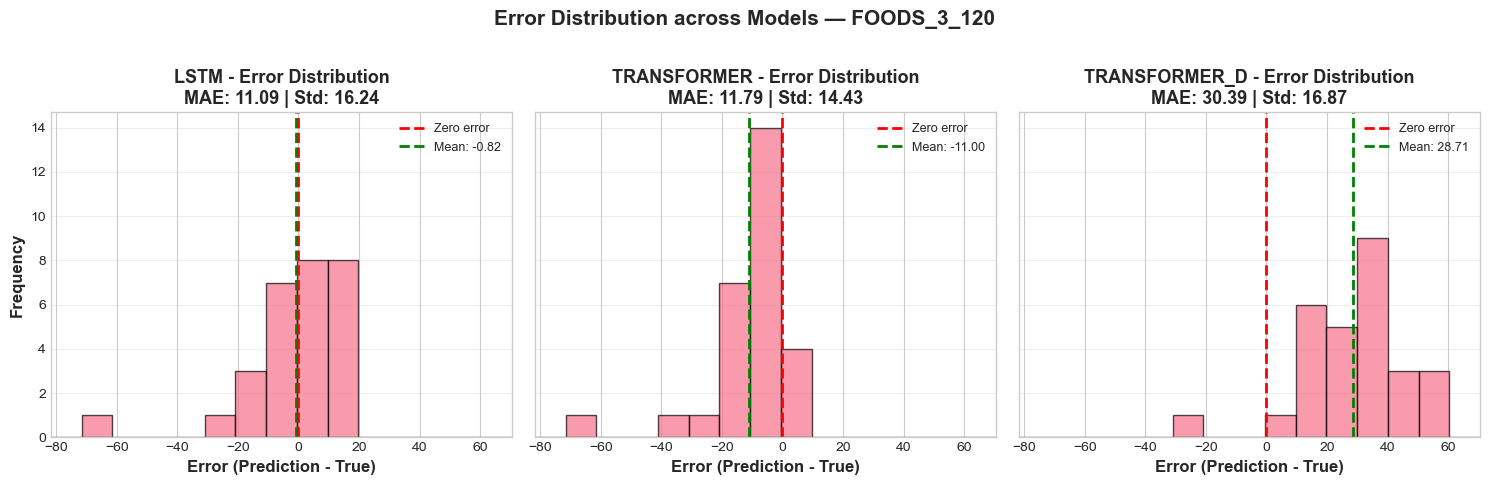

In [16]:
plot_error_distribution(
    results,
    selected_item,
    save_path=f"../images/error_dist_{selected_item}.png"
)

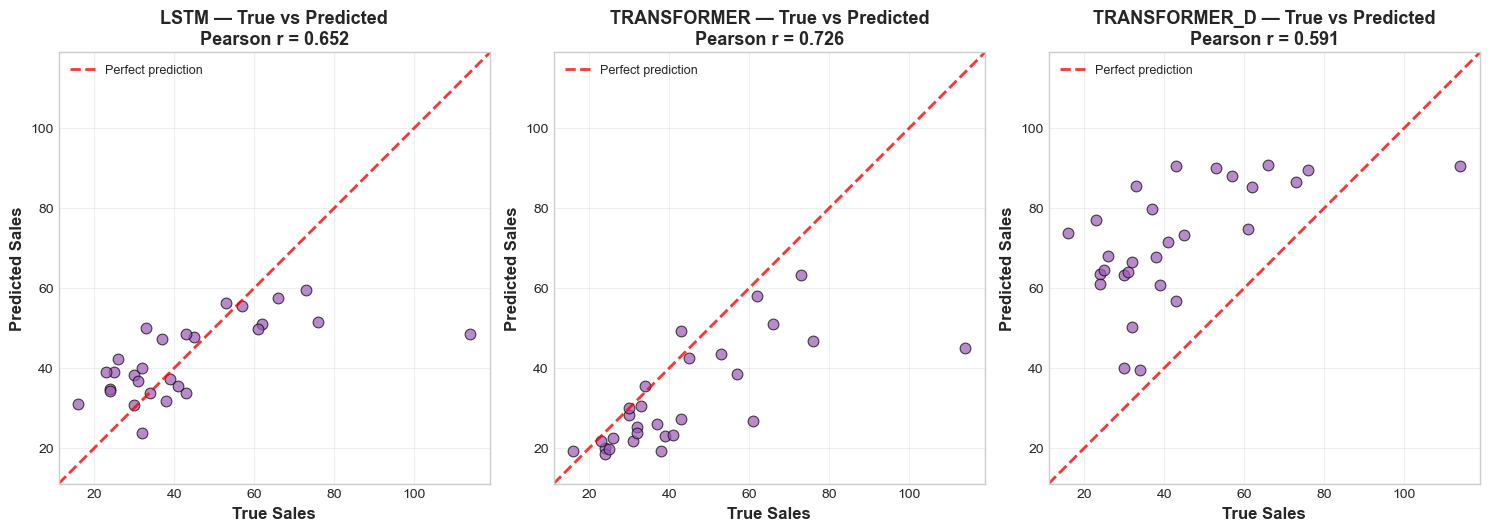

In [17]:
def plot_true_vs_pred_scatter(results_dict, item_id, save_path=None):
    """
    Plot scatter plots: True vs Predicted for all models (same scale for easy comparison).

    results_dict: dict like {"lstm": df_lstm, "transformer": df_tf, "transformer_d": df_tfd}
                  each df must contain columns: ['item_id', 'day_offset', 'true_real', 'pred_real']
    item_id:      item to visualize, e.g. 'FOODS_3_120'
    """
    all_true = []
    all_pred = []
    for df in results_dict.values():
        item_data = df[df["item_id"] == item_id]
        if not item_data.empty:
            all_true.append(item_data["true_real"].values)
            all_pred.append(item_data["pred_real"].values)

    if len(all_true) == 0:
        print(f"[Warning] No data found for item_id = {item_id}")
        return

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    global_min = min(all_true.min(), all_pred.min())
    global_max = max(all_true.max(), all_pred.max())

    padding = (global_max - global_min) * 0.05 if global_max > global_min else 1.0
    x_min, x_max = global_min - padding, global_max + padding

    fig, axes = plt.subplots(1, len(results_dict), figsize=(5 * len(results_dict), 5))
    if len(results_dict) == 1:
        axes = [axes]

    for idx, (model_name, df) in enumerate(results_dict.items()):
        item_data = df[df["item_id"] == item_id].sort_values("day_offset")
        true_vals = item_data["true_real"].values
        pred_vals = item_data["pred_real"].values

        ax = axes[idx]

        ax.scatter(
            true_vals,
            pred_vals,
            alpha=0.7,
            s=60,
            color="#9b59b6",
            edgecolors="black",
            linewidth=0.8,
        )

        ax.plot(
            [x_min, x_max],
            [x_min, x_max],
            "r--",
            linewidth=2,
            label="Perfect prediction",
            alpha=0.8,
        )

        from scipy.stats import pearsonr
        if (
            len(true_vals) > 1
            and np.std(true_vals) > 1e-9
            and np.std(pred_vals) > 1e-9
        ):
            corr, _ = pearsonr(true_vals, pred_vals)
            corr_text = f"Pearson r = {corr:.3f}"
        else:
            corr_text = "Pearson r = N/A"

        ax.set_xlabel("True Sales", fontsize=12, fontweight="bold")
        ax.set_ylabel("Predicted Sales", fontsize=12, fontweight="bold")
        ax.set_title(
            f"{model_name.upper()} — True vs Predicted\n{corr_text}",
            fontsize=13,
            fontweight="bold",
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(x_min, x_max)
        ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_true_vs_pred_scatter(
    results, selected_item,
    save_path=f"../images/scatter_{selected_item}.png"
)